### Ablation experiment-Frequency-Only

In [1]:
from matplotlib import font_manager
import matplotlib.pyplot as plt
# register and use Arial font in Matplotlib figures
font_manager.fontManager.addfont('ARIAL.TTF')
# Set global plotting defaults
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'Arial',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})

In [2]:
# Set random seeds for reproducibility 
import glob
import numpy as np
import random
import torch
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

##### Data Loading

In [3]:
# Load CuP traces from .npy files and split them into train/val/test subsets with a fixed random seed
def load_and_split_traces(npy_path, label, seed=42):
    data = np.load(npy_path, allow_pickle=True)  
    traces = list(data)
    
    # Reproducible shuffling
    random.seed(seed)
    random.shuffle(traces)
    n_total = len(traces)
    n_train = int(n_total * 0.43)
    n_val = int(n_total * 0.11)
    n_test = n_total - n_train - n_val
    train_samples = [(t, label) for t in traces[:n_train]]
    val_samples   = [(t, label) for t in traces[n_train:n_train + n_val]]
    test_samples  = [(t, label) for t in traces[n_train + n_val:]]
    return train_samples, val_samples, test_samples

cup_paths = glob.glob("../data/CuP-TPH/CuP-0.1mM_train_val_test.npy")
cup_train_samples = []
cup_val_samples = []
cup_test_samples = []

for path in cup_paths:
    # Label=0 for CuP class; use the same seed to keep splits consistent across runs
    train_part, val_part, test_part = load_and_split_traces(path, label=0, seed=42)
    cup_train_samples.extend(train_part)
    cup_val_samples.extend(val_part)
    cup_test_samples.extend(test_part)

# Quick sanity check of split sizes
print(f"CuP training trace count: {len(cup_train_samples)}")
print(f"CuP validation trace count: {len(cup_val_samples)}")
print(f"CuP test trace count: {len(cup_test_samples)}")

CuP training trace count: 1849
CuP validation trace count: 473
CuP test trace count: 1978


In [4]:
# Load CuP+TPH traces from .npy files, split them into train/val/test subsets, 
# and merge with the CuP (negative) samples.
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import os

tph_paths = glob.glob("../data/CuP-TPH/CuP+TPH-1_2(0.2mM)_train_val.npy")
tph_train_samples = []
tph_val_samples = []
tph_test_samples = []
for path in tph_paths:
    data = np.load(path, allow_pickle=True)
    traces = list(data)  
    # Reproducible shuffle before splitting
    random.seed(42)
    random.shuffle(traces)
    n_total = len(traces)
    n_train = int(n_total * 0.8)
    n_val = n_total - n_train
    tph_train_samples.extend([(t, 1) for t in traces[:n_train]])
    tph_val_samples.extend([(t, 1) for t in traces[n_train:]])

# Merge positives with CuP negatives to form final train/val sets  
train_samples = cup_train_samples + tph_train_samples
val_samples   = cup_val_samples   + tph_val_samples

# Quick sanity check of split sizes
print(f"TPH training trace count: {len(tph_train_samples)}")
print(f"TPH validation trace count: {len(tph_val_samples)}")

TPH training trace count: 1820
TPH validation trace count: 456


In [5]:
# Dataset wrapper that converts each 1D conductance trace into paired time-domain 
# and frequency-domain (FFT magnitude) inputs.
class TraceDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        trace, label = self.samples[idx]
        trace = np.array(trace, dtype=np.float32)
        # Time-domain input
        x_time = torch.tensor(trace).unsqueeze(0)  
        # Frequency-domain input
        freq = np.fft.rfft(trace)
        mag = np.abs(freq)
        x_freq = torch.tensor(mag[np.newaxis, :], dtype=torch.float32)

        return x_time, x_freq, label

##### Model

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class TFC(nn.Module):
    def __init__(self, configs):
        super(TFC, self).__init__()
        
        # Time-domain encoder
        self.encoder_time = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=9, padding=4),
            nn.InstanceNorm1d(64, affine=True),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            
            nn.Flatten(),
            nn.Linear(128 * 750, 128),

            nn.LayerNorm(128), 
            nn.GELU(),
            nn.Dropout(0.25)
        )
        
        # Frequency-domain encoder
        self.encoder_freq = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.InstanceNorm1d(64, affine=True),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.InstanceNorm1d(128, affine=True),
            nn.GELU(),
            
            nn.Flatten(),
            nn.Linear(128 * 375, 128),
                
            nn.LayerNorm(128), 
            nn.GELU(),
            nn.Dropout(0.25)
        )

        # Projection heads
        self.projector_t = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU()
        )
        
        self.projector_f = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU()
        )

    def forward(self, x_in_t, x_in_f, mode="both"):
        # Return encoder features (h_*) and projected features (z_*)
        h_t, h_f = None, None
        z_t, z_f = None, None

        # Compute time branch if requested
        if mode in ["both", "time"]:
            h_t = self.encoder_time(x_in_t)  
            z_t = self.projector_t(h_t)       

        # Compute frequency branch if requested    
        if mode in ["both", "freq"]:
            h_f = self.encoder_freq(x_in_f)   
            z_f = self.projector_f(h_f)        

        return h_t, h_f, z_t, z_f

# classifier
class target_classifier(nn.Module):
    def __init__(self, configs):
        super(target_classifier, self).__init__()
        # classifier on concatenated (time, freq) features
        self.logits = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),       
            nn.Linear(128 * 2, 64), 
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, h_t, h_f):
         # In time-domain mode, use time-domain features
         # In frequency-domain mode, use frequency-domain features
         # In time-frequency fusion mode, use both time-domain and frequency-domain features
        if h_t is None: h_t = torch.zeros_like(h_f)
        if h_f is None: h_f = torch.zeros_like(h_t)
        
        h = torch.cat([h_t, h_f], dim=1) 
        out = self.logits(h)
        return out

##### Model Training (load model)

In [7]:
# Basic configs and device setup
class Config:
    TSlength_aligned_t = 1500
    TSlength_aligned_f = 751
    num_classes_target = 2

configs = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build model + classifier and load checkpoint weights
tfc_model = TFC(configs).to(device)
classifier = target_classifier(configs).to(device)

checkpoint = torch.load("checkpoint_freq_(CuP+TPH).pth")
tfc_model.load_state_dict(checkpoint['tfc_model_state_dict'])
classifier.load_state_dict(checkpoint['classifier_state_dict'])

# Switch to evaluation mode
tfc_model.eval()
classifier.eval()

target_classifier(
  (logits): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report,accuracy_score
from mpl_toolkits.axes_grid1 import make_axes_locatable
from collections import Counter
import matplotlib.colors as mcolors

# Evaluate the model
def evaluate(tfc_model, classifier, dataloader, mode="both", return_acc=False, save_path=None):
    tfc_model.eval()
    classifier.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x_t, x_f, y in dataloader:
            x_t, x_f = x_t.to(device), x_f.to(device)
            h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
            logits = classifier(h_t, h_f)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
            
    # Metrics summary
    print(f"\n[Mode={mode}] Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    acc = accuracy_score(all_labels, all_preds)
    print(f"[Mode={mode}] Accuracy: {acc:.4f}")

    # Plot confusion matrix only when meaningful (>=2 classes and not perfect accuracy)
    unique_labels = np.unique(all_labels)
    if (acc < 1.0) and (len(unique_labels) >= 2):
        cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

        with np.errstate(divide='ignore', invalid='ignore'):
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)

        display_labels = ["CuP", "CuP+CAF"]
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Custom colormap for better contrast
        colors = ["#FFFFFF", "#F3A697", "#F17D65"]
        cmap_custom = mcolors.LinearSegmentedColormap.from_list("white_to_red", colors)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                                      display_labels=display_labels)
        disp.plot(cmap=cmap_custom, values_format='.3f', ax=ax, colorbar=False)
        
        # Colorbar and axis styling
        im = disp.im_
        im.set_clim(0, 1)

        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=20)
        cbar.ax.yaxis.label.set_size(22)

        plt.setp(ax.get_yticklabels(), ha="right", multialignment="center", fontsize=20)
        ax.set_xlabel("Predicted label", fontsize=22, fontweight='normal')
        ax.set_ylabel("True label", fontsize=22, fontweight='normal')
        plt.setp(ax.get_xticklabels(), ha='center', fontsize=20)
        plt.setp(ax.get_yticklabels(), rotation=90, va='center', fontsize=20)

        for text in disp.ax_.texts:
            text.set_fontsize(22)
            val = disp.confusion_matrix[int(text.get_position()[1])][int(text.get_position()[0])]
            text.set_color('white' if val > 0.5 else 'black')

        plt.tight_layout()

        # Save figure if requested
        if save_path:
            dir_name = os.path.dirname(save_path)
            if dir_name:
                os.makedirs(dir_name, exist_ok=True)
            plt.savefig(save_path, dpi=600, bbox_inches='tight')

        plt.show()

    else:
        if len(unique_labels) < 2:
            print("Only one true class is present; skipping confusion matrix plotting.")
        else:
            print("Accuracy is 100%; skipping confusion matrix plotting.")

    if return_acc:
        return acc

    
# Report the predicted class distribution over a dataloader
def predict_class_distribution(tfc_model, classifier, dataloader, device):
    tfc_model.eval()
    classifier.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_t, x_f, y in dataloader:
            x_t, x_f = x_t.to(device), x_f.to(device)
            h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
            logits = classifier(h_t, h_f)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    counter = Counter(all_preds)
    total = sum(counter.values())
    for cls_idx in sorted(counter.keys()):
        count = counter[cls_idx]
        percent = 100 * count / total
    return counter

In [9]:
# Load traces from multiple .npy files and attach a class label to each trace.
# Return a list of (trace, label) pairs.
def load_trace_level_samples(file_label_pairs):
    samples = []
    for path, label in file_label_pairs:
        data = np.load(path, allow_pickle=True) 
        for trace in data:
            trace = np.array(trace, dtype=np.float32)
            samples.append((trace, label))
    return samples

#   "both" = time-frequency fusion 
#   "time" = only-time-domain 
#   "freq" = only-frequency-domain
# Choose mode: "freq"
mode = "freq"

##### CuP-test

In [10]:
# Build CuP test set (force label=0)
# Run evaluation + prediction distribution check
final_test_samples = [(trace, 0) for trace, _ in cup_test_samples]
final_test_loader = DataLoader(TraceDataset(final_test_samples), batch_size=32, shuffle=False)

evaluate(tfc_model, classifier, final_test_loader, mode=mode)
predict_class_distribution(tfc_model, classifier, final_test_loader, device)


[Mode=freq] Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.7659    0.8674      1978
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.7659      1978
   macro avg     0.5000    0.3830    0.4337      1978
weighted avg     1.0000    0.7659    0.8674      1978

[Mode=freq] Accuracy: 0.7659
Only one true class is present; skipping confusion matrix plotting.


/root/miniconda3/envs/wzyEnv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/envs/wzyEnv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/envs/wzyEnv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Counter({0: 1515, 1: 463})

##### Prediction

In [11]:
# Compute predicted TPH proportion for each concentration (used for a calibration curve)
manual_paths = [
    ("../data/CuP-TPH/CuP+TPH-100_1(0.001mM)_prediction.npy", 1E-6),
    ("../data/CuP-TPH/CuP+TPH-1000_1(0.0001mM)_prediction.npy", 1E-7),
    ("../data/CuP-TPH/CuP+TPH-100000_1(0.000001mM)_prediction.npy", 1E-9),
    ("../data/CuP-TPH/CuP+TPH-1000000_1(0.0000001mM)_prediction.npy", 1E-10),
    ("../data/CuP-TPH/CuP+TPH-10^8_1(10^-12mM)_prediction.npy", 1E-12),
    ("../data/CuP-TPH/CuP+TPH-10^11_1(10^-15mM)_prediction.npy", 1E-15),
    ("../data/CuP-TPH/CuP+TPH-10^12_1(10^-16mM)_prediction.npy", 1E-16),
    ("../data/CuP-TPH/CuP+TPH-10^14_1(10^-18mM)_prediction.npy", 1E-18),
]

# Store (concentration, predicted TPH ratio) for downstream plotting/fitting
concentration_list = []
caf_proportion_list = []
for path, conc in manual_paths:
    try:
        # Load traces
        samples = load_trace_level_samples([(path, 1)])
        if len(samples) == 0:
            continue
        loader = DataLoader(TraceDataset(samples), batch_size=32, shuffle=False, drop_last=True)
        tfc_model.eval()
        classifier.eval()
        
        # Collect predicted class ids over all traces in this concentration file
        preds = []
        with torch.no_grad():
            for x_t, x_f, _ in loader:
                x_t, x_f = x_t.to(device), x_f.to(device)
                h_t, h_f, z_t, z_f = tfc_model(x_t, x_f, mode=mode)
                out = classifier(h_t, h_f)
                
                pred = torch.argmax(out, dim=1).cpu().numpy()
                preds.extend(pred.tolist())
        count = Counter(preds)
        total = len(preds)
        ratio = count.get(1, 0) / total
        print(f"[MODE={mode}] {conc:.1e} mM: TPH Ratio = {ratio:.2f}")

        concentration_list.append(conc)
        caf_proportion_list.append(ratio)
    except Exception as e:
        # Skip corrupted/missing files without breaking the whole sweep
        print(f"error")

[MODE=freq] 1.0e-06 mM: TPH Ratio = 0.73
[MODE=freq] 1.0e-07 mM: TPH Ratio = 0.69
[MODE=freq] 1.0e-09 mM: TPH Ratio = 0.57
[MODE=freq] 1.0e-10 mM: TPH Ratio = 0.65
[MODE=freq] 1.0e-12 mM: TPH Ratio = 0.50
[MODE=freq] 1.0e-15 mM: TPH Ratio = 0.46
[MODE=freq] 1.0e-16 mM: TPH Ratio = 0.56
[MODE=freq] 1.0e-18 mM: TPH Ratio = 0.28


##### Limit of Detection

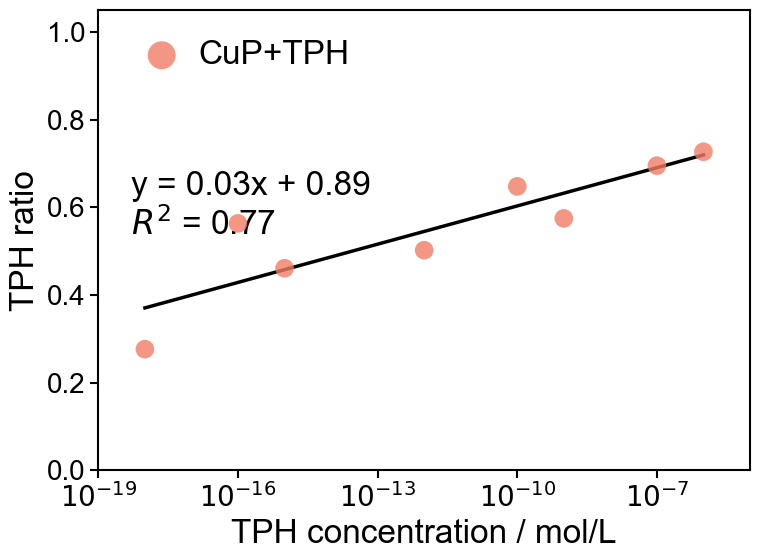

In [12]:
# Plot the calibration curve by regressing the predicted TPH ratio against log10(concentration) 
# and visualizing the fit on a log-scaled x-axis.
import matplotlib.ticker as ticker
from scipy.stats import linregress
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

# Keep only valid (positive) concentrations
valid_indices = [i for i, c in enumerate(concentration_list) if c > 0]
concentration_array = np.array(concentration_list)[valid_indices]
proportion_array = np.array(caf_proportion_list)[valid_indices]

# Linear regression in log-space: y = slope * log10(c) + intercept
log_conc = np.log10(concentration_array)
slope, intercept, r_value, _, _ = linregress(log_conc, proportion_array)

# Build fitted line in log-space, then convert x back to linear for plotting
log_x_min = np.log10(min(concentration_array))
log_x_max = np.log10(max(concentration_array))
fit_x = np.linspace(log_x_min, log_x_max, 100)
fit_y = slope * fit_x + intercept
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter: measured points (concentration vs predicted TPH ratio)
ax.scatter(concentration_array, proportion_array, 
           marker='o', s=180, c='#F17D65', alpha=0.8, edgecolors='none',zorder=10, label='CuP+TPH')

# Fit curve: plot using linear concentration values (10**fit_x) with fitted y
ax.plot(10**fit_x, fit_y, '-', color='black', lw=2.5)

# Axes setup 
ax.set_xscale("log")
ax.set_ylim(0, 1.05)
ax.set_xlim(min(concentration_array) * 0.1, max(concentration_array) * 10)
ax.set_xlabel("TPH concentration / mol/L", fontsize=24, fontweight='normal')
ax.set_ylabel("TPH ratio", fontsize=24, fontweight='normal')

# Format log x-axis ticks as 10^k
def sci_notation_formatter(x, pos):
    if x == 0:
        return "0"
    exponent = int(np.log10(x))
    return r"$10^{{{}}}$".format(exponent)
ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0]))
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation_formatter))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(1.5)
ax.tick_params(width=1.5, length=6)

# Annotate regression equation and R^2 on the plot
sign = '+' if intercept >= 0 else '-'
equation_text = (
    f"y = {slope:.2f}x {sign} {abs(intercept):.2f}\n"
    f"$R^2$ = {r_value**2:.2f}"
)
ax.text(0.05, 0.65, equation_text,
        transform=ax.transAxes,
        fontsize=24,
        verticalalignment='top')

ax.legend(loc='upper left', fontsize=24, frameon=False, handletextpad=0.1, markerscale=1.5)

# Save figure for reporting
plt.tight_layout()
save_path = f"../results/CuP_TPH_{mode}_LOD.png"
plt.savefig(save_path, format='png', dpi=330, bbox_inches='tight')
plt.show()